# 05 · Performance metrics and ANOVA

**Question.** How well does each of the 480 pipeline runs recover the truth set (precision, recall, F1), and which pipeline settings explain the differences?

**Reviewer comment.** None.

**Reads.** `data/derived/sets_dict.parquet` (the variant set of each run), the truth VCF `data/truth/hc_bed_filtered.recode.vcf`, `data/reference/TestCases.csv` and `data/reference/sequencing_yield.csv` (Table 1 annotations). It never reads `data/raw/`; no run VCF is parsed. The truth VCF is parsed here because no truth-set cache exists yet.

**Metrics.** Each run's set is scored against the whole truth set (`swb.metrics`): IoU, precision, recall and F1. The same definitions produce the whole-study rows of `union_metrics.csv`.

**SomaticSniper asymmetry.** SomaticSniper VCFs have `FILTER = .` on every record, so the PASS filter is not applied to them (legacy behaviour); Mutect and Strelka are PASS-filtered. Every metric of a SomaticSniper run inherits this.

**Produces** (`results/05_metrics_anova/`):
- `tables/run_metrics.csv`: one row per run: settings, IoU, precision, recall and F1.
- `tables/f1_by_sample.csv`: mean, maximum and minimum F1 per sample and over all runs.
- `tables/factor_tests.csv`: for precision, recall and F1, the paired t-tests of mapper, base recalibration and trimming, the pairwise caller t-tests and the one-way ANOVA of the caller, each under its own label (D6).
- `tables/pairing.csv`: how many of the position pairs of those paired t-tests are runs that differ in the tested setting alone (D6).
- `tables/anova_f1.csv`: the full-factorial ANOVA of F1 (7 factors, 127 terms), Type II sums of squares (D4), with each term's share of the total.
- `tables/anova_f1_type3.csv`: the Type III ANOVA of F1 on five factors (mapper, caller, center, trimming, base recalibration), with each term's share of the total sum of squares, F statistic and −log10(p-value).
- `figures/precision_recall_by_run`, `figures/precision_by_setting` and `figures/variance_by_source`, the legacy figures of these results.
- `figures/precision_recall_by_setting`: box plots of precision (upper panel) and recall (lower panel) by mapper, variant caller, base recalibration and trimming, with the p-value of each parameter below it. The medians and p-values are also shown as a table under it.

**Legacy.** The legacy notebook printed the F1 summaries, the factor tests (for precision) and the variance table. Parity reproduces those printed values and the whole-study rows of `union_metrics.csv`. Recall and F1 tests, the pairing table and the ANOVA terms below 1% were not printed and are reported as not compared.

**Type III ANOVA and its p-values (D13).** The 7-factor model above has one run per cell, so it has no residual and no p-values. For `anova_f1_type3.csv` and the figure `anova_contribution_significance`, environment and duplicate handling are treated as replicates: 120 cells of 4 runs, 360 residual degrees of freedom. The design is balanced, so Type III (sum-to-zero contrasts) equals Type II, and each term's share is the one in the 7-factor table. But the four runs of a cell are near-identical, so the residual is tiny and every term has a p-value far below 1e-300; `minus_log10_p` is computed in log space because the p-value itself underflows to 0. These p-values carry no information about which terms matter (D13).

**Paired tests (D6).** `ttest_rel` pairs the k-th run of one level with the k-th run of the other, in run order, as legacy does. `pairing.csv` shows this pairs comparable runs for the mapper and the callers, but not for base recalibration and trimming.

**Does not.** Draw the legacy interactive figures, or change the legacy pairing of the tests.

## Imports

In [1]:
import sys
from pathlib import Path

try:
    import swb  # noqa: F401
except ImportError:  # swb is not pip-installed: use the repository's src/ (notebooks run from notebooks/)
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from swb import audit, config, io, metrics, stats, viz

## Config

In [2]:
OUT = config.results_dir("05_metrics_anova")
STAGE = audit.Stage(OUT / ".staging")

EXPECTED_RUNS = 480
LEVELS = config.FACTOR_LEVELS
TEST_METRICS = ["Precision", "Recall", "f1_score"]
FACTORS_TYPE3 = ["isTrimmed", "baseRecalibration", "Mapper", "VariantCaller", "Center"]  # environment and duplicates are the replicates
TOLERANCE = 1e-12          # recomputed metrics differ from the legacy CSV by about 1e-16
PRINTED_TOLERANCE = 5e-7   # values the legacy notebook printed with 6 decimals
# The paired comparisons of the legacy factor tests: setting, first level, second level
PAIRED = [("Mapper", "BWA", "BOWTIE"), ("baseRecalibration", "YES", "NO"), ("isTrimmed", "YES", "NO"),
          ("VariantCaller", "Mutect", "SomaticSniper"), ("VariantCaller", "Mutect", "Strelka"),
          ("VariantCaller", "SomaticSniper", "Strelka")]

## Load + validate

In [3]:
assert config.SETS_PARQUET.exists(), "run 01_variant_sets first"
sets = io.load_sets(config.SETS_PARQUET)
assert len(sets) == EXPECTED_RUNS and all(sets.values()), "the cache does not hold {} non-empty runs".format(EXPECTED_RUNS)

meta = pd.read_csv(config.METADATA_CSV)
assert list(meta.columns) == config.METADATA_COLUMNS, list(meta.columns)
runs = io.study_runs(meta, sets, LEVELS, rename=config.METADATA_RENAME)
assert len(runs) == EXPECTED_RUNS, len(runs)
assert runs.index.is_monotonic_increasing  # ascending run number: the row order of the legacy tables

truth = io.truth_set(str(config.TRUTH_VCF))
assert len(truth) > 0

# Sequencing yield and coverage per sample (manuscript Table 1); panel order = increasing yield
yield_table = io.sequencing_yield(config.SEQUENCING_YIELD_CSV, LEVELS["Sample"])
panel_order = yield_table["Sample"].tolist()
panel_notes = viz.yield_panel_notes(yield_table)
print("{} runs, {} truth variants".format(len(runs), len(truth)))

480 runs, 1161 truth variants


## Analysis

In [4]:
scores = pd.DataFrame([(metrics.jaccard(sets[k], truth),) + metrics.prf1(sets[k], truth) for k in runs["TestCaseNo"]],
                      index=runs.index, columns=["Inter/Union", "Precision", "Recall", "f1_score"])
assert scores.notna().all().all() and scores.ge(0).all().all() and scores.le(1).all().all()
df = runs.join(scores)
df["Center"] = df["Sample"]  # the ANOVA calls the sample "Center"

run_metrics = df.reset_index()[["run", "Sample", "Environment", "isTrimmed", "baseRecalibration", "Mapper",
                                "VariantCaller", "Duplicates", "Inter/Union", "Precision", "Recall", "f1_score"]]
by_sample = df.groupby("Sample")["f1_score"].agg(n_runs="size", mean="mean", max="max", min="min").reset_index()
overall = pd.DataFrame([{"Sample": "all", "n_runs": len(df), "mean": df["f1_score"].mean(),
                         "max": df["f1_score"].max(), "min": df["f1_score"].min()}])
f1_by_sample = pd.concat([by_sample, overall], ignore_index=True)
f1_by_sample.round(4)

,Sample,n_runs,mean,max,min
0,EA,96,0.7390,0.8979,0.4982
1,FD,96,0.5829,0.8316,0.0779
2,IL,96,0.7679,0.9218,0.5680
3,LL,96,0.6168,0.8361,0.1405
4,NC,96,0.7500,0.8808,0.5021
5,all,480,0.6913,0.9218,0.0779


In [5]:
flat = df.reset_index(drop=True)  # ascending run order, as legacy: ttest_rel pairs rows by position (D6)
factor_tests = pd.DataFrame(
    [(metric, comparison, stat, p) for metric in TEST_METRICS
     for comparison, (stat, p) in stats.factor_tests(flat, metric).items()],
    columns=["metric", "comparison", "statistic", "p_value"])
pairing = pd.DataFrame(
    [("{}: {} vs {}".format(setting, first, second),) + stats.positional_pair_match(flat, setting, first, second, list(LEVELS))
     for setting, first, second in PAIRED], columns=["comparison", "n_pairs", "n_matched"])
assert factor_tests["p_value"].between(0, 1).all()
pairing

,comparison,n_pairs,n_matched
0,Mapper: BWA vs BOWTIE,240,240
1,baseRecalibration: YES vs NO,240,72
2,isTrimmed: YES vs NO,240,72
3,VariantCaller: Mutect vs SomaticSniper,160,160
4,VariantCaller: Mutect vs Strelka,160,160
5,VariantCaller: SomaticSniper vs Strelka,160,160


In [6]:
anova_table = stats.fit_anova(df, "f1_score", typ=2)  # about half a minute
variance = stats.variance_pct(anova_table, min_pct=1)
anova_out = pd.DataFrame({"source": anova_table.index, "df": anova_table["df"].to_numpy(),
                          "sum_sq": anova_table["sum_sq"].to_numpy(),
                          "percent": (anova_table["sum_sq"] / anova_table["sum_sq"].sum() * 100).to_numpy()})
assert len(anova_out) == 128 and abs(anova_out["percent"].sum() - 100) < 1e-9  # 127 terms and the residual
variance.round(3)

/opt/miniconda3/envs/mywork2_rebuild_env/lib/python3.8/site-packages/statsmodels/stats/anova.py:142: RuntimeWarning: divide by zero encountered in scalar divide
  (model.ssr / model.df_resid))


,Result
Source,
C(VariantCaller),53.945
C(Center),19.391
C(Mapper):C(VariantCaller),7.964
C(VariantCaller):C(Center),3.579
C(isTrimmed):C(Mapper):C(VariantCaller),2.635
C(isTrimmed):C(VariantCaller),2.446
C(isTrimmed):C(Mapper),1.798
C(isTrimmed),1.591
C(baseRecalibration),1.238


In [7]:
type3 = stats.fit_anova(df, "f1_score", factors=FACTORS_TYPE3, typ=3)
type2 = stats.fit_anova(df, "f1_score", factors=FACTORS_TYPE3, typ=2)
terms3 = type3.drop("Residual")
df_resid = int(type3.loc["Residual", "df"])
total_ss = type3["sum_sq"].sum()
assert df_resid == len(df) - df.groupby(FACTORS_TYPE3).ngroups, "residual degrees of freedom are not runs minus cells"
assert len(terms3) == 2 ** len(FACTORS_TYPE3) - 1
# Balanced design: Types II and III coincide (D4)
assert np.allclose(terms3["sum_sq"], type2.loc[terms3.index, "sum_sq"], rtol=1e-9, atol=1e-9 * total_ss)
type3_out = pd.DataFrame({
    "term": terms3.index, "label": [stats.term_label(t) for t in terms3.index], "df": terms3["df"].to_numpy(),
    "sum_sq": terms3["sum_sq"].to_numpy(), "percent": (terms3["sum_sq"] / total_ss * 100).to_numpy(),
    "F": terms3["F"].to_numpy(),
    "minus_log10_p": [stats.neg_log10_p(f, d, df_resid) for f, d in zip(terms3["F"], terms3["df"])],
}).sort_values("percent", ascending=False).reset_index(drop=True)
residual_share = type3.loc["Residual", "sum_sq"] / total_ss
type3_out.head(6).round(3)

,term,label,df,sum_sq,percent,F,minus_log10_p
0,C(VariantCaller),VC,2.0,7.715,53.945,2.890482e+10,1477.026
1,C(Center),CEN,4.0,2.773,19.391,5.195115e+09,1394.786
2,C(Mapper):C(VariantCaller),MP + VC,2.0,1.139,7.964,4.267284e+09,1327.478
3,C(VariantCaller):C(Center),VC + CEN,8.0,0.512,3.579,4.793960e+08,1258.945
4,C(isTrimmed):C(Mapper):C(VariantCaller),TRM + MP + VC,2.0,0.377,2.635,1.411786e+09,1241.009
5,C(isTrimmed):C(VariantCaller),TRM + VC,2.0,0.350,2.446,1.310834e+09,1235.210


## Save tables

Written to staging; moved to `results/05_metrics_anova/` only if parity passes.

In [8]:
io.write_csv(run_metrics, STAGE.path(OUT / "tables" / "run_metrics.csv"), sort_by="run")
io.write_csv(f1_by_sample, STAGE.path(OUT / "tables" / "f1_by_sample.csv"), sort_by="Sample")
io.write_csv(factor_tests, STAGE.path(OUT / "tables" / "factor_tests.csv"), sort_by=["metric", "comparison"])
io.write_csv(pairing, STAGE.path(OUT / "tables" / "pairing.csv"), sort_by="comparison")
io.write_csv(anova_out, STAGE.path(OUT / "tables" / "anova_f1.csv"), sort_by="source")
io.write_csv(type3_out, STAGE.path(OUT / "tables" / "anova_f1_type3.csv"), sort_by="term")

## Figures

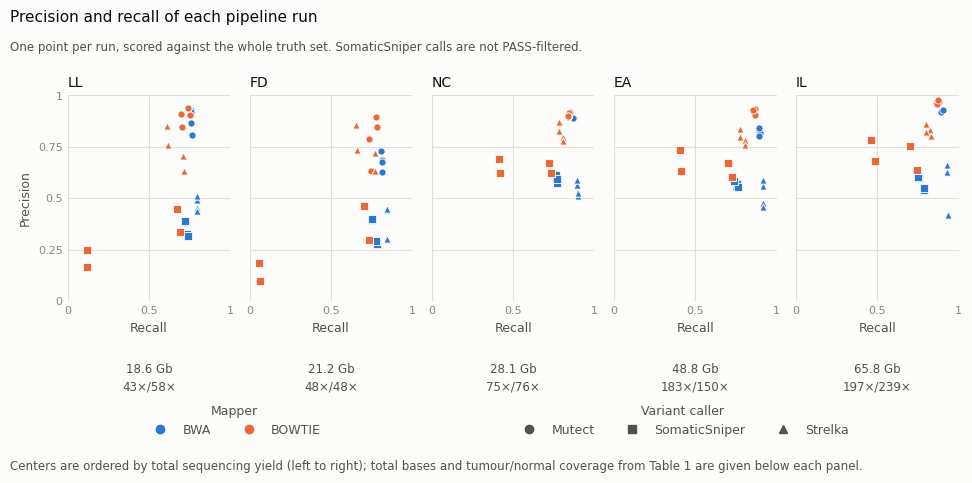

In [9]:
fig, axes = viz.precision_recall_panels(
    df.reset_index(), samples=panel_order, panel_notes=panel_notes, caption=viz.YIELD_CAPTION,
    title="Precision and recall of each pipeline run",
    subtitle="One point per run, scored against the whole truth set. SomaticSniper calls are not PASS-filtered.")
viz.save_fig(fig, STAGE.stem(OUT / "figures" / "precision_recall_by_run"))
plt.show()

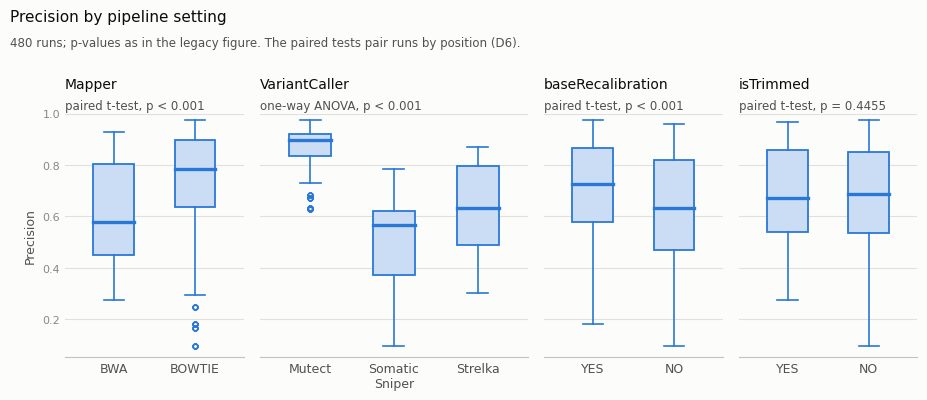

In [10]:
res = factor_tests[factor_tests["metric"] == "Precision"].set_index("comparison")["p_value"]
tests = {"Mapper": ("paired t-test", res["Mapper"]), "VariantCaller": ("one-way ANOVA", res["VariantCaller (one-way ANOVA)"]),
         "baseRecalibration": ("paired t-test", res["baseRecalibration"]), "isTrimmed": ("paired t-test", res["isTrimmed"])}
fig, axes = viz.factor_boxplots(
    df.reset_index(), "Precision", tests, ylabel="Precision", title="Precision by pipeline setting",
    subtitle="480 runs; p-values as in the legacy figure. The paired tests pair runs by position (D6).")
viz.save_fig(fig, STAGE.stem(OUT / "figures" / "precision_by_setting"))
plt.show()

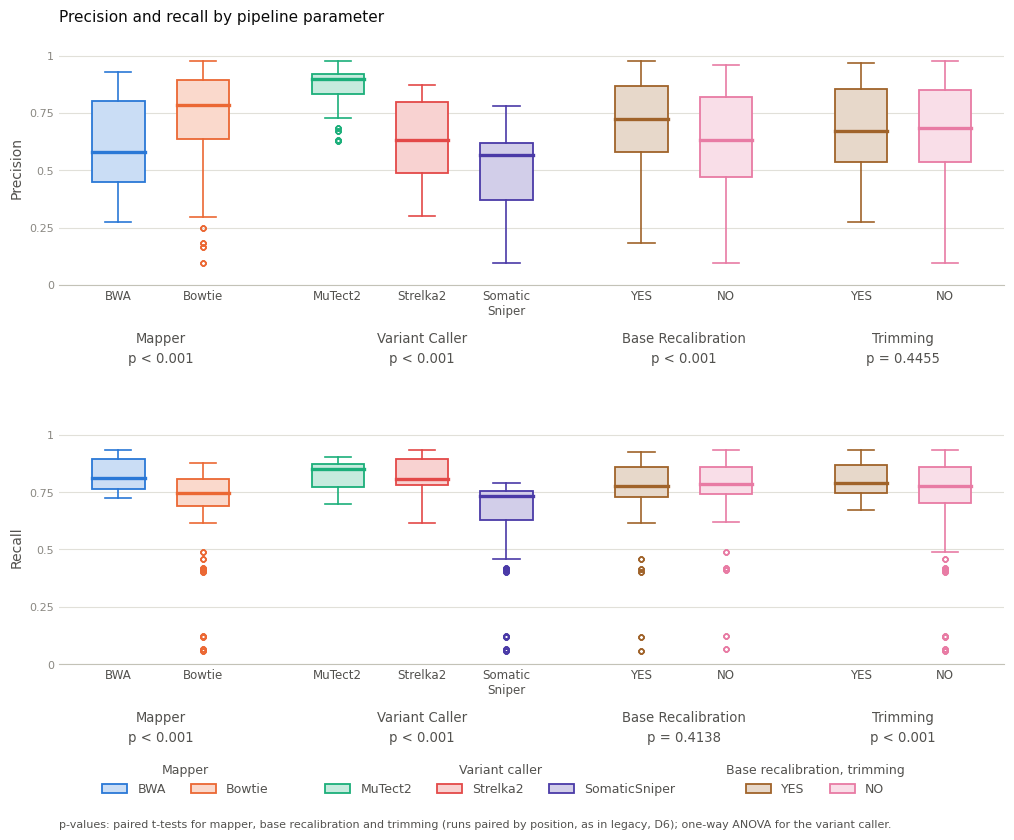

,parameter,level,Precision,Recall,p_precision,p_recall
0,Mapper,BOWTIE,0.7844,0.7459,0.0000,0.0000
1,Mapper,BWA,0.5780,0.8118,0.0000,0.0000
2,VariantCaller,Mutect,0.8968,0.8523,0.0000,0.0000
3,VariantCaller,SomaticSniper,0.5648,0.7321,0.0000,0.0000
4,VariantCaller,Strelka,0.6322,0.8062,0.0000,0.0000
5,baseRecalibration,NO,0.6320,0.7842,0.0000,0.4138
6,baseRecalibration,YES,0.7246,0.7765,0.0000,0.4138
7,isTrimmed,NO,0.6852,0.7769,0.4455,0.0000
8,isTrimmed,YES,0.6707,0.7911,0.4455,0.0000


In [11]:
p_values = {}
for metric in ("Precision", "Recall"):
    res = factor_tests[factor_tests["metric"] == metric].set_index("comparison")["p_value"]
    p_values[metric] = {"Mapper": res["Mapper"], "VariantCaller": res["VariantCaller (one-way ANOVA)"],
                        "baseRecalibration": res["baseRecalibration"], "isTrimmed": res["isTrimmed"]}
fig, axes = viz.precision_recall_boxplots(
    df.reset_index(), p_values, title="Precision and recall by pipeline parameter",
    footnote="p-values: paired t-tests for mapper, base recalibration and trimming (runs paired by position, as in legacy, D6); "
             "one-way ANOVA for the variant caller.")
viz.save_fig(fig, STAGE.stem(OUT / "figures" / "precision_recall_by_setting"))
plt.show()
# Table view: median precision and recall of each level, and the p-value of each parameter
levels_table = pd.concat([
    df.groupby(factor)[["Precision", "Recall"]].median().rename_axis("level").reset_index().assign(parameter=factor)
    .assign(p_precision=p_values["Precision"][factor], p_recall=p_values["Recall"][factor])
    for factor in ("Mapper", "VariantCaller", "baseRecalibration", "isTrimmed")], ignore_index=True)
levels_table[["parameter", "level", "Precision", "Recall", "p_precision", "p_recall"]].round(4)

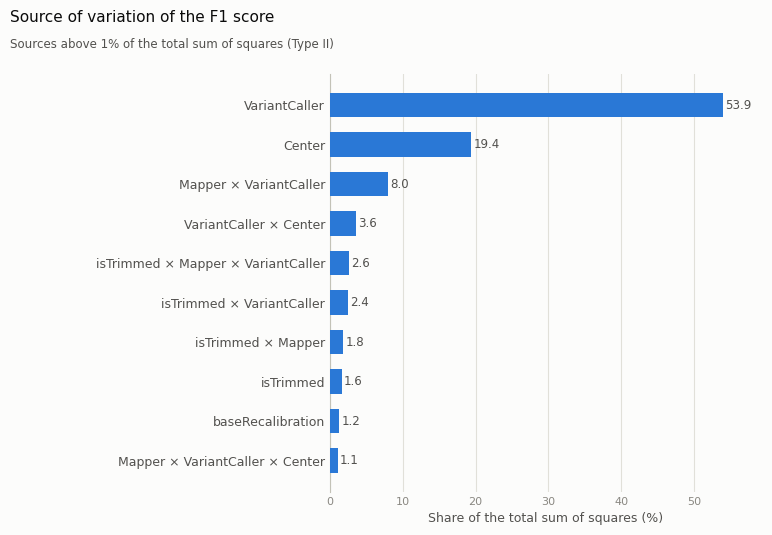

In [12]:
fig, ax = viz.variance_bars(
    variance["Result"], title="Source of variation of the F1 score",
    subtitle="Sources above 1% of the total sum of squares (Type II)")
viz.save_fig(fig, STAGE.stem(OUT / "figures" / "variance_by_source"))
plt.show()

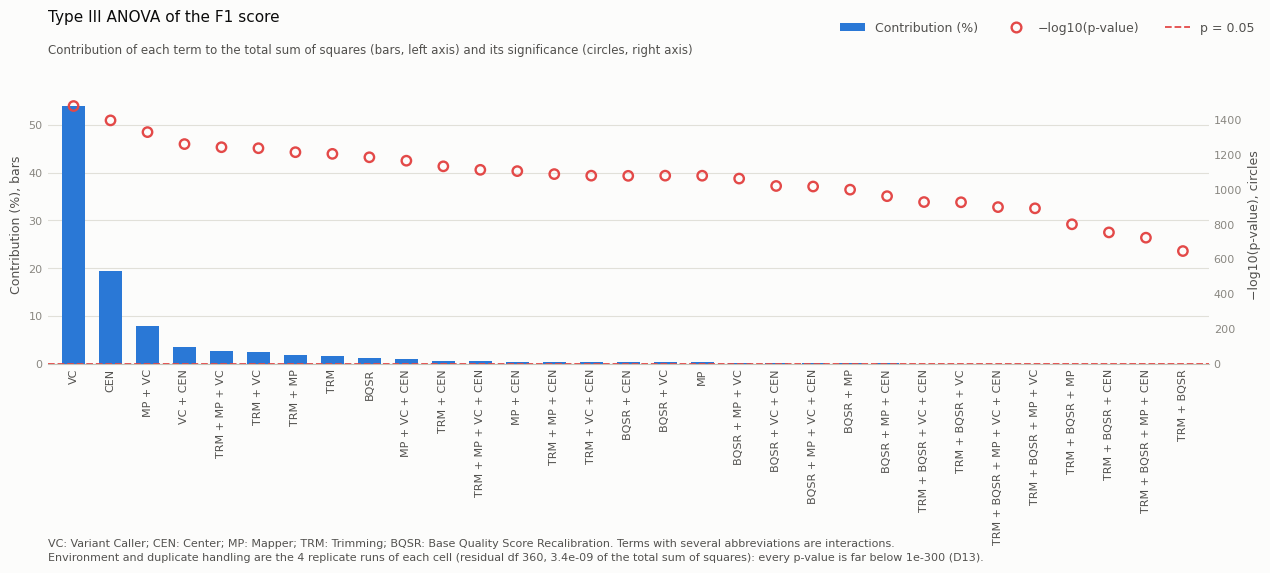

In [13]:
fig, ax, ax2 = viz.anova_contribution_significance(
    type3_out, title="Type III ANOVA of the F1 score",
    subtitle="Contribution of each term to the total sum of squares (bars, left axis) and its significance (circles, right axis)",
    footnote="VC: Variant Caller; CEN: Center; MP: Mapper; TRM: Trimming; BQSR: Base Quality Score Recalibration. "
             "Terms with several abbreviations are interactions.\n"
             "Environment and duplicate handling are the 4 replicate runs of each cell (residual df {}, {:.1e} of the total sum of squares): "
             "every p-value is far below 1e-300 (D13).".format(df_resid, residual_share))
viz.save_fig(fig, STAGE.stem(OUT / "figures" / "anova_contribution_significance"))
plt.show()

## Parity check

Against the legacy tables and the values the legacy notebook printed (`data/derived/legacy_metrics_recorded.csv`):
- IoU, precision, recall and F1 of every run equal the whole-study rows of `union_metrics.csv` (1e-12);
- the F1 summaries (cell 126), the F1 of the first five runs (132), the seven printed factor tests for precision (128) and the ten variance sources above 1% (134). The values printed with 6 decimals are compared to 5e-7, the others to 1e-9 relative;
- the printed "Mapper" test line equals the base recalibration test, as D6 says.

The printed factor tests are the text of `stats.factor_tests_legacy`, parsed back. Everything else is reported as not compared. Results are moved out of staging only if every check that ran passes.

In [14]:
recorded = pd.read_csv(config.LEGACY_METRICS_RECORDED)
parity = audit.Parity()

# Whole-study rows of union_metrics.csv
union = pd.read_csv(config.LEGACY_UNION_METRICS, dtype={"TestCase": str})
whole = union[union["Region"].str.lower() == "findings from this study"].copy()
whole["TestCase"] = whole["TestCase"].map(io.canon)
mine = df.set_index("TestCaseNo")[["Inter/Union", "Precision", "Recall", "f1_score"]]
worst = max(float(np.abs(whole[c].values - mine.loc[whole["TestCase"], c].values).max()) for c in mine.columns)
parity.check("IoU, precision, recall and F1 == whole-study rows of union_metrics.csv (all {} rows)".format(len(whole)),
             set(whole["TestCase"]) == set(mine.index) and worst <= TOLERANCE, "max |diff| {:.2e}".format(worst))

# F1 summaries and the first runs (cells 126 and 132)
by_sample_rec = recorded[recorded["kind"] == "f1_by_sample"].assign(Sample=lambda r: r["key"].str.upper())
ours = by_sample.set_index("Sample")[["mean", "max", "min"]].stack()
d_sample = np.array([abs(ours[(r.Sample, r.stat)] - r.value) for r in by_sample_rec.itertuples()])
parity.check("F1 mean, max and min per sample == legacy cell 126 ({} values)".format(len(d_sample)),
             len(d_sample) == 3 * len(LEVELS["Sample"]) and d_sample.max() <= PRINTED_TOLERANCE, "max |diff| {:.2e}".format(d_sample.max()))
overall_rec = recorded[recorded["kind"] == "f1_overall"].set_index("stat")["value"]
d_overall = max(abs(overall.iloc[0][s] - v) for s, v in overall_rec.items())
parity.check("F1 mean, max and min over all runs == legacy cell 126", len(overall_rec) == 3 and d_overall <= TOLERANCE,
             "max |diff| {:.2e}".format(d_overall))
first_rec = recorded[recorded["kind"] == "f1_first_runs"]
d_first = np.array([abs(mine.loc[r.key, "f1_score"] - r.value) for r in first_rec.itertuples()])
parity.check("F1 of the first {} runs == legacy cell 132".format(len(d_first)), len(d_first) > 0 and d_first.max() <= PRINTED_TOLERANCE,
             "max |diff| {:.2e}".format(d_first.max()))

# Factor tests for precision (cell 128): the printed text, reproduced and parsed back
printed = {}
for line in stats.factor_tests_legacy(flat, "Precision").splitlines():
    m = re.match(r"^(.+?)\s*:: T-Test: t-statistic = (\S+), p-value ?[:=] ?(\S+)\s*$", line)
    if m:
        printed[m.group(1).strip()] = (float(m.group(2)), float(m.group(3)))
rec_tests = recorded[recorded["kind"] == "factor_test_precision"].pivot(index="key", columns="stat", values="value")
same = set(printed) == set(rec_tests.index) and all(
    np.isclose(printed[k][0], rec_tests.loc[k, "statistic"], rtol=1e-9, atol=0)
    and np.isclose(printed[k][1], rec_tests.loc[k, "p_value"], rtol=1e-9, atol=0) for k in rec_tests.index)
parity.check("factor tests for precision == the {} lines legacy cell 128 printed (statistic and p-value)".format(len(rec_tests)),
             same, "{} lines".format(len(printed)))
correct = factor_tests[factor_tests["metric"] == "Precision"].set_index("comparison")["statistic"]
printed_mapper = rec_tests.loc["Mapper", "statistic"]
parity.check("the printed 'Mapper' line is the base recalibration test, not the mapper test (D6)",
             np.isclose(printed_mapper, correct["baseRecalibration"], rtol=1e-9, atol=0)
             and not np.isclose(printed_mapper, correct["Mapper"], rtol=1e-6, atol=0),
             "printed {:.6f}; base recalibration {:.6f}; mapper {:.6f}".format(
                 printed_mapper, correct["baseRecalibration"], correct["Mapper"]))

# Variance table (cell 134): the sources above 1%, in order
var_rec = recorded[recorded["kind"] == "variance_pct"].sort_values("order").reset_index(drop=True)  # the printed rank order
ours_var = variance["Result"]
d_var = (np.abs(ours_var.to_numpy() - var_rec["value"].to_numpy()) if len(ours_var) == len(var_rec) else np.array([np.inf]))
parity.check("sources above 1% and their shares == legacy cell 134 ({} sources, same order)".format(len(var_rec)),
             ours_var.index.tolist() == var_rec["key"].tolist() and d_var.max() <= PRINTED_TOLERANCE,
             "max |diff| {:.2e}".format(d_var.max()))
pct3 = type3_out.set_index("term")["percent"].reindex(var_rec["key"]).to_numpy()
parity.check("shares of the same {} sources in the 5-factor Type III ANOVA == legacy cell 134 (balanced design)".format(len(var_rec)),
             not np.isnan(pct3).any() and np.abs(pct3 - var_rec["value"].to_numpy()).max() <= PRINTED_TOLERANCE,
             "max |diff| {:.2e}".format(np.abs(pct3 - var_rec["value"].to_numpy()).max()))
parity.skip("recall and F1 tests, pairing.csv, the ANOVA terms below 1%, the Type III F statistics and p-values, the figures",
            "not printed by the legacy notebook; computed from the verified metrics")

parity.finish(OUT / "audit" / "parity.txt", STAGE)

parity: PASS (8 checks, 1 skipped)
PASS  IoU, precision, recall and F1 == whole-study rows of union_metrics.csv (all 1440 rows)  [max |diff| 2.22e-16]
PASS  F1 mean, max and min per sample == legacy cell 126 (15 values)  [max |diff| 4.36e-07]
PASS  F1 mean, max and min over all runs == legacy cell 126  [max |diff| 5.55e-17]
PASS  F1 of the first 5 runs == legacy cell 132  [max |diff| 4.35e-07]
PASS  factor tests for precision == the 7 lines legacy cell 128 printed (statistic and p-value)  [7 lines]
PASS  the printed 'Mapper' line is the base recalibration test, not the mapper test (D6)  [printed 13.601269; base recalibration 13.601269; mapper -13.717256]
PASS  sources above 1% and their shares == legacy cell 134 (10 sources, same order)  [max |diff| 4.73e-07]
PASS  shares of the same 10 sources in the 5-factor Type III ANOVA == legacy cell 134 (balanced design)  [max |diff| 4.73e-07]
SKIP  recall and F1 tests, pairing.csv, the ANOVA terms below 1%, the Type III F statistics and p-value

## Audit summary

In [15]:
top = variance["Result"].head(3).round(2).to_dict()
lines = [
    "runs: {}; truth variants: {}; F1 {:.3f}-{:.3f} (mean {:.3f})".format(
        len(df), len(truth), df["f1_score"].min(), df["f1_score"].max(), df["f1_score"].mean()),
    "IoU, precision, recall and F1 reproduce the whole-study rows of union_metrics.csv (max |diff| {:.1e})".format(worst),
    "printed legacy values reproduced: F1 by sample, F1 of the first runs, {} factor-test lines (precision), {} variance sources".format(
        len(rec_tests), len(var_rec)),
    "SomaticSniper is not PASS-filtered (FILTER is '.' on every record; legacy exemption preserved); its metrics inherit this",
    "",
    "ANOVA of F1: 7 factors, {} terms, Type II sums of squares (D4); largest sources: {}".format(len(anova_out) - 1, top),
    "Type III ANOVA (5 factors; environment and duplicates are replicates): residual df {}, residual {:.1e} of the total sum of squares; F {:.1e}-{:.1e}; -log10(p) {:.0f}-{:.0f}".format(
        df_resid, residual_share, type3_out["F"].min(), type3_out["F"].max(), type3_out["minus_log10_p"].min(), type3_out["minus_log10_p"].max()),
    "  every one of the {} terms has p far below 0.05 and below 1e-300; the residual comes from runs that differ only in environment and duplicate handling (D13)".format(len(type3_out)),
    "D6: the paired t-tests pair the k-th run of one level with the k-th of the other, in run order (as legacy). Pairs that differ in the tested setting alone:",
] + ["  {}: {} of {}".format(r.comparison, r.n_matched, r.n_pairs) for r in pairing.itertuples()] + [
    "",
    "not compared with legacy: recall and F1 tests, pairing.csv, ANOVA terms below 1%, Type III F and p-values, the figures",
    "",
    "python {} | pandas {}".format(sys.version.split()[0], pd.__version__),
]
(OUT / "audit").mkdir(parents=True, exist_ok=True)
(OUT / "audit" / "summary.txt").write_text("\n".join(lines) + "\n")
print("\n".join(lines))

runs: 480; truth variants: 1161; F1 0.078-0.922 (mean 0.691)
IoU, precision, recall and F1 reproduce the whole-study rows of union_metrics.csv (max |diff| 2.2e-16)
printed legacy values reproduced: F1 by sample, F1 of the first runs, 7 factor-test lines (precision), 10 variance sources
SomaticSniper is not PASS-filtered (FILTER is '.' on every record; legacy exemption preserved); its metrics inherit this

ANOVA of F1: 7 factors, 127 terms, Type II sums of squares (D4); largest sources: {'C(VariantCaller)': 53.94, 'C(Center)': 19.39, 'C(Mapper):C(VariantCaller)': 7.96}
Type III ANOVA (5 factors; environment and duplicates are replicates): residual df 360, residual 3.4e-09 of the total sum of squares; F 9.6e+05-2.9e+10; -log10(p) 646-1477
  every one of the 31 terms has p far below 0.05 and below 1e-300; the residual comes from runs that differ only in environment and duplicate handling (D13)
D6: the paired t-tests pair the k-th run of one level with the k-th of the other, in run order (